# 1. Importing Required Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

## 2. Importing (Reading) Dataset

In [8]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('diabetes.csv')

print(data.shape)
data.head()

(500, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,9,140,59,24,107,45.3,0.223,21,1
1,11,123,80,34,190,35.9,0.996,25,1
2,0,93,69,40,315,38.8,0.306,21,0
3,11,71,61,29,110,18.1,0.647,29,0
4,6,123,79,24,239,15.0,0.080,26,0


## 3. Checking for Any Null Values in Dataset

In [9]:
data.isnull().sum()

pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

## 4. Assigning Independent and Dependent Variables

In [10]:
feature_cols = ['pregnant', 'insulin', 'bmi',
                'age', 'glucose', 'bp', 'pedigree']

x = data[feature_cols]
y = data.label

## 5. Splitting the Dataset into Training and Testing Dataset

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=5
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(400, 7)

(400,)

(100, 7)

(100,)

## 6. Fitting the Model (Decision Tree Classifier)

In [12]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 7. Predicting the Test Data

In [13]:
y_pred = model.predict(x_test)

print('y_pred:', y_pred)

y_pred: [1 1 1 0 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 0 1 1
 0 0 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0
 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1]


## 8. Confusion Matrix

In [14]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print('Confusion Matrix:')
print(conf_mat)

Confusion Matrix:
[[22 17]
 [15 46]]


## 9. Accuracy Score

In [15]:
Accuracy_score = metrics.accuracy_score(y_test, y_pred)

print('Accuracy Score:', Accuracy_score)

print('Accuracy in Percentage:',
      int(Accuracy_score * 100), '%')

Accuracy Score: 0.68
Accuracy in Percentage: 68 %


## 10. Confusion Matrix using Heatmap

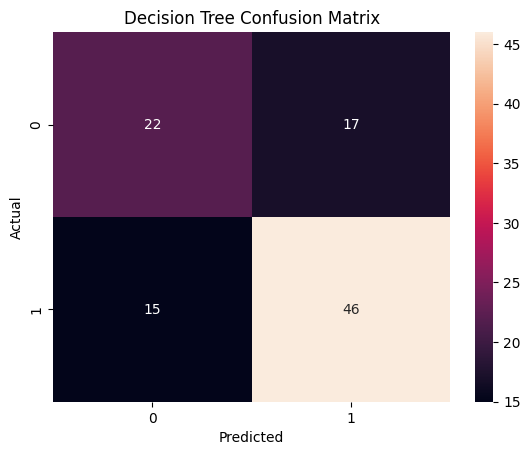

In [16]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True, fmt='d')

plt.title('Decision Tree Confusion Matrix')
plt.show()

In [17]:
print(tree.export_text(model, feature_names=feature_cols))

|--- glucose <= 133.50
|   |--- bmi <= 37.85
|   |   |--- glucose <= 93.50
|   |   |   |--- pregnant <= 8.50
|   |   |   |   |--- pregnant <= 2.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- pregnant >  2.50
|   |   |   |   |   |--- bmi <= 31.45
|   |   |   |   |   |   |--- age <= 59.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- age >  59.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- bmi >  31.45
|   |   |   |   |   |   |--- pregnant <= 6.50
|   |   |   |   |   |   |   |--- age <= 52.00
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- age >  52.00
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- pregnant >  6.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |--- pregnant >  8.50
|   |   |   |   |--- pedigree <= 0.34
|   |   |   |   |   |--- insulin <= 124.50
|   |   |   |   |   |   |--- age <= 29.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   